# 🏠 House Price Prediction — Complete ML Project
> **Data Cleaning → EDA → Feature Engineering → Modeling → Flask Web App**

---

## 📦 Step 1 — Install & Import Libraries

In [1]:
# Install required packages (run once)
import subprocess, sys
for pkg in ['pandas','numpy','matplotlib','seaborn','scikit-learn','flask','flask-cors','joblib','ipywidgets']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('✅ All packages installed!')

✅ All packages installed!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json, threading
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib
plt.style.use('seaborn-whitegrid')
sns.set_palette('husl')
print('✅ Libraries imported!')

✅ Libraries imported!


---
## 📊 Step 2 — Generate / Load Dataset

In [4]:
np.random.seed(42)
n = 1000

locations   = np.random.choice(['Downtown','Suburbs','Rural','Waterfront','Midtown'], n,
                                p=[0.20, 0.35, 0.15, 0.10, 0.20])
loc_mult    = {'Downtown':1.4,'Suburbs':1.0,'Rural':0.7,'Waterfront':1.8,'Midtown':1.2}

sqft        = np.random.randint(600, 4500, n)
bedrooms    = np.random.randint(1, 6, n)
bathrooms   = np.clip(bedrooms - np.random.randint(0,2,n), 1, 5)
age         = np.random.randint(0, 60, n)
garage      = np.random.choice([0, 1, 2], n, p=[0.20, 0.50, 0.30])
pool        = np.random.choice([0, 1], n, p=[0.80, 0.20])
floors      = np.random.choice([1, 2, 3], n, p=[0.50, 0.35, 0.15])
condition   = np.random.choice(['Poor','Fair','Good','Excellent'], n, p=[0.10,0.20,0.50,0.20])

cond_map    = {'Poor':0.85,'Fair':0.95,'Good':1.05,'Excellent':1.20}

base_price  = (sqft * 150
               + bedrooms * 8000
               + bathrooms * 6000
               - age * 500
               + garage * 10000
               + pool * 25000
               + floors * 5000)

price = (base_price
         * np.array([loc_mult[l] for l in locations])
         * np.array([cond_map[c] for c in condition])
         + np.random.normal(0, 15000, n))

price = np.clip(price, 50000, 3000000)

# Inject ~5% missing values for realism
df = pd.DataFrame({
    'Location':   locations,
    'SqFt':       sqft.astype(float),
    'Bedrooms':   bedrooms.astype(float),
    'Bathrooms':  bathrooms.astype(float),
    'Age':        age.astype(float),
    'Garage':     garage.astype(float),
    'Pool':       pool.astype(float),
    'Floors':     floors.astype(float),
    'Condition':  condition,
    'Price':      price
})

for col in ['SqFt','Bedrooms','Age']:
    mask = np.random.choice([True,False], n, p=[0.05,0.95])
    df.loc[mask, col] = np.nan

df.to_csv('house_prices.csv', index=False)
print(f'✅ Dataset created: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

✅ Dataset created: 1000 rows × 10 columns


,Location,SqFt,Bedrooms,Bathrooms,Age,Garage,Pool,Floors,Condition,Price
0,Suburbs,4486.0,5.0,5.0,20.0,1.0,0.0,3.0,Good,801477.504490
1,Midtown,611.0,4.0,3.0,23.0,2.0,0.0,3.0,Excellent,248246.658546
2,Waterfront,1941.0,NaN,3.0,41.0,1.0,0.0,1.0,Good,647949.402755
3,Rural,4263.0,5.0,5.0,59.0,2.0,0.0,2.0,Poor,389813.716434
4,Downtown,815.0,NaN,3.0,39.0,1.0,0.0,1.0,Good,245576.742040
5,Downtown,938.0,3.0,3.0,1.0,1.0,0.0,2.0,Fair,286802.067537
6,Downtown,2399.0,2.0,1.0,54.0,1.0,0.0,2.0,Good,549161.663633
7,Midtown,3308.0,4.0,3.0,7.0,2.0,0.0,2.0,Good,686529.413195
8,Rural,3752.0,2.0,2.0,47.0,1.0,0.0,3.0,Good,415974.906377
9,Waterfront,2350.0,2.0,1.0,26.0,1.0,0.0,2.0,Good,725963.547745


---
## 🔍 Step 3 — Exploratory Data Analysis (EDA)

In [5]:
print('='*55)
print('         DATASET OVERVIEW')
print('='*55)
print(f'Shape      : {df.shape}')
print(f'Duplicates : {df.duplicated().sum()}')
print('\n--- Missing Values ---')
miss = df.isnull().sum()
print(miss[miss>0].to_string())
print('\n--- Data Types ---')
print(df.dtypes.to_string())

         DATASET OVERVIEW
Shape      : (1000, 10)
Duplicates : 0

--- Missing Values ---
SqFt        45
Bedrooms    56
Age         55

--- Data Types ---
Location      object
SqFt         float64
Bedrooms     float64
Bathrooms    float64
Age          float64
Garage       float64
Pool         float64
Floors       float64
Condition     object
Price        float64


In [6]:
df.describe().round(2)

,SqFt,Bedrooms,Bathrooms,Age,Garage,Pool,Floors,Price
count,955.00,944.00,1000.00,945.00,1000.00,1000.0,1000.00,1000.00
mean,2531.67,3.05,2.66,30.20,1.08,0.2,1.64,514702.81
std,1150.87,1.42,1.37,17.89,0.69,0.4,0.72,265974.46
min,601.00,1.00,1.00,0.00,0.00,0.0,1.00,74658.83
25%,1537.00,2.00,1.00,15.00,1.00,0.0,1.00,305334.36
50%,2516.00,3.00,3.00,30.00,1.00,0.0,1.00,464958.23
75%,3586.00,4.00,4.00,46.00,2.00,0.0,2.00,672908.46
max,4499.00,5.00,5.00,59.00,2.00,1.0,3.00,1516686.56


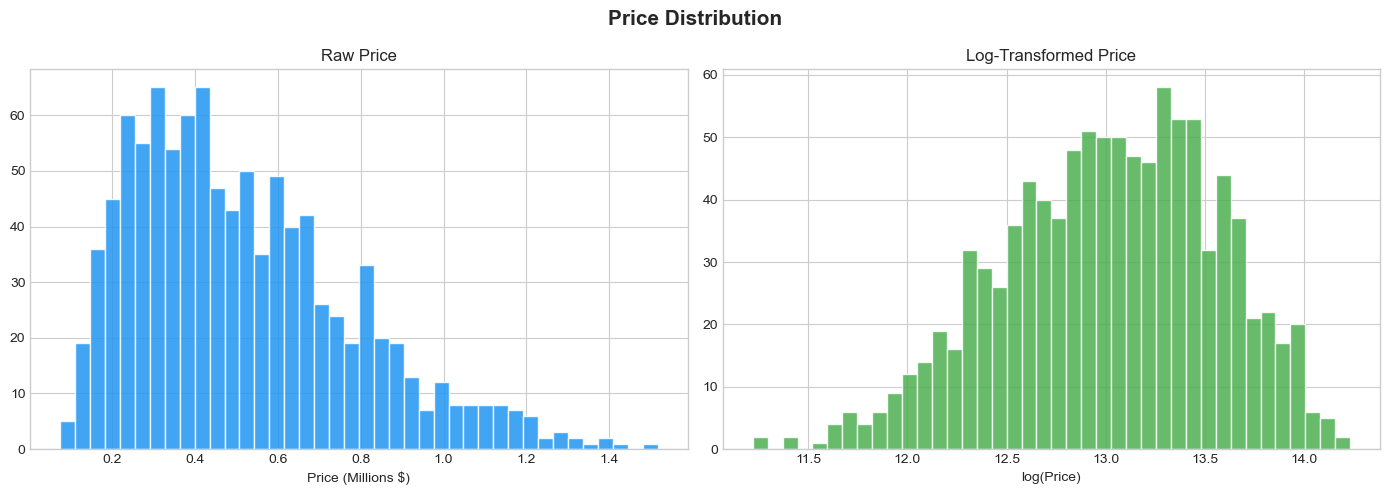

In [7]:
# --- Price Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Distribution', fontsize=15, fontweight='bold')

axes[0].hist(df['Price']/1e6, bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title('Raw Price')
axes[0].set_xlabel('Price (Millions $)')

axes[1].hist(np.log1p(df['Price']), bins=40, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[1].set_title('Log-Transformed Price')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.savefig('plot_price_dist.png', dpi=120, bbox_inches='tight')
plt.show()

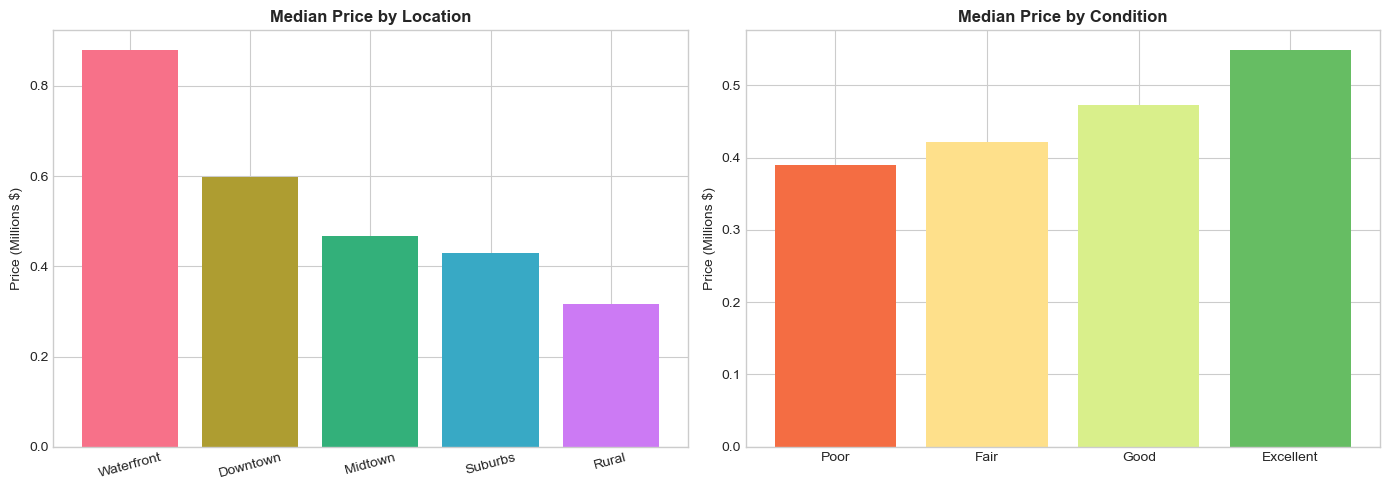

In [8]:
# --- Average Price by Location & Condition ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

loc_avg = df.groupby('Location')['Price'].median().sort_values(ascending=False)
axes[0].bar(loc_avg.index, loc_avg.values/1e6, color=sns.color_palette('husl', len(loc_avg)))
axes[0].set_title('Median Price by Location', fontweight='bold')
axes[0].set_ylabel('Price (Millions $)')
axes[0].tick_params(axis='x', rotation=15)

cond_avg = df.groupby('Condition')['Price'].median().reindex(['Poor','Fair','Good','Excellent'])
axes[1].bar(cond_avg.index, cond_avg.values/1e6, color=sns.color_palette('RdYlGn', 4))
axes[1].set_title('Median Price by Condition', fontweight='bold')
axes[1].set_ylabel('Price (Millions $)')

plt.tight_layout()
plt.savefig('plot_categorical.png', dpi=120, bbox_inches='tight')
plt.show()

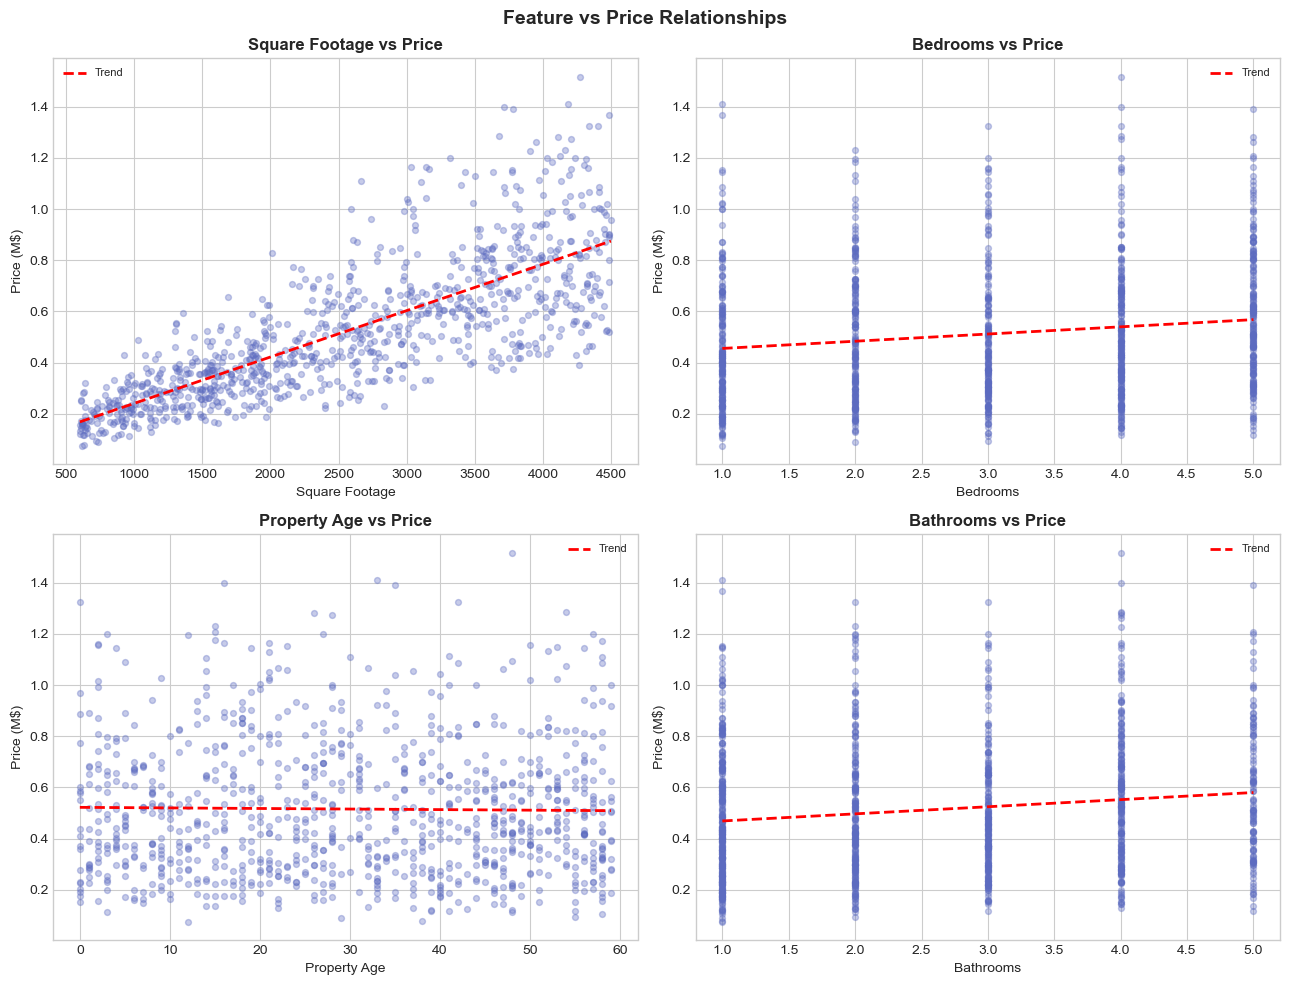

In [9]:
# --- Scatter plots ---
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Feature vs Price Relationships', fontsize=14, fontweight='bold')

pairs = [('SqFt','Square Footage'), ('Bedrooms','Bedrooms'),
         ('Age','Property Age'), ('Bathrooms','Bathrooms')]

for ax, (col, label) in zip(axes.flat, pairs):
    tmp = df.dropna(subset=[col])
    ax.scatter(tmp[col], tmp['Price']/1e6, alpha=0.35, s=18, color='#5C6BC0')
    ax.set_xlabel(label)
    ax.set_ylabel('Price (M$)')
    ax.set_title(f'{label} vs Price', fontweight='bold')
    z = np.polyfit(tmp[col].dropna(), tmp.loc[tmp[col].notna(),'Price']/1e6, 1)
    p = np.poly1d(z)
    xline = np.linspace(tmp[col].min(), tmp[col].max(), 100)
    ax.plot(xline, p(xline), 'r--', lw=2, label='Trend')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 🔧 Step 4 — Data Cleaning & Feature Engineering

In [10]:
df_clean = df.copy()

# --- Fill missing numerics with median ---
num_cols = ['SqFt','Bedrooms','Bathrooms','Age']
for col in num_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# --- Feature Engineering ---
df_clean['PricePerSqFt']     = df_clean['Price'] / df_clean['SqFt']
df_clean['RoomRatio']        = df_clean['Bedrooms'] / (df_clean['Bathrooms'] + 1)
df_clean['TotalRooms']       = df_clean['Bedrooms'] + df_clean['Bathrooms']
df_clean['IsNew']            = (df_clean['Age'] <= 5).astype(int)
df_clean['HasAmenities']     = ((df_clean['Pool'] == 1) | (df_clean['Garage'] >= 1)).astype(int)
df_clean['SqFt_log']         = np.log1p(df_clean['SqFt'])
df_clean['Age_sq']           = df_clean['Age'] ** 2

# --- Encode Categoricals ---
df_clean = pd.get_dummies(df_clean, columns=['Location','Condition'], drop_first=True)

print('✅ Cleaned shape:', df_clean.shape)
df_clean[['SqFt','PricePerSqFt','RoomRatio','TotalRooms','IsNew','HasAmenities']].describe().round(2)

✅ Cleaned shape: (1000, 22)


,SqFt,PricePerSqFt,RoomRatio,TotalRooms,IsNew,HasAmenities
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,2530.97,210.70,0.81,5.70,0.10,0.85
std,1124.66,68.54,0.21,2.69,0.31,0.36
min,601.00,56.51,0.50,2.00,0.00,0.00
25%,1562.50,163.94,0.67,3.00,0.00,1.00
50%,2516.00,201.45,0.83,6.00,0.00,1.00
75%,3542.25,247.66,1.00,8.00,0.00,1.00
max,4499.00,499.02,1.50,10.00,1.00,1.00


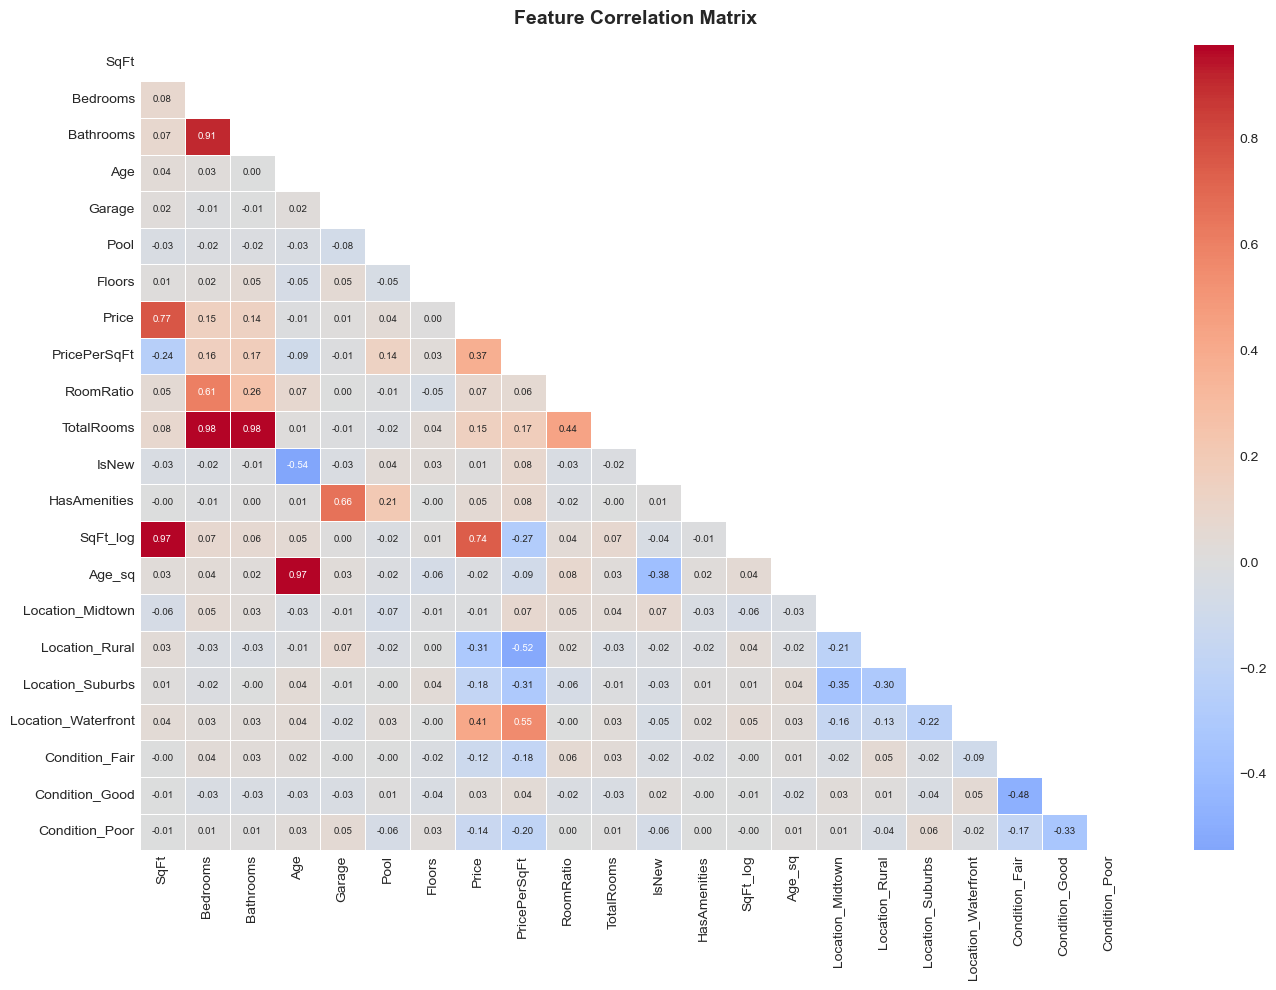

In [11]:
# --- Correlation Heatmap ---
num_df = df_clean.select_dtypes(include=np.number)
corr   = num_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size':7})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_corr.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 🤖 Step 5 — Model Building & Evaluation

In [12]:
# Drop helper columns not used in training
drop_cols = ['PricePerSqFt']
feature_cols = [c for c in df_clean.columns if c not in ['Price'] + drop_cols]

X = df_clean[feature_cols]
y = df_clean['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f'Train size : {X_train.shape[0]}')
print(f'Test size  : {X_test.shape[0]}')
print(f'Features   : {X_train.shape[1]}')

Train size : 800
Test size  : 200
Features   : 20


In [13]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds   = model.predict(X_te)
    r2      = r2_score(y_te, preds)
    rmse    = np.sqrt(mean_squared_error(y_te, preds))
    mae     = mean_absolute_error(y_te, preds)
    cv_r2   = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()
    print(f'  {name:<22} R²={r2:.4f}  CV-R²={cv_r2:.4f}  RMSE=${rmse:,.0f}  MAE=${mae:,.0f}')
    return {'name':name,'model':model,'r2':r2,'rmse':rmse,'mae':mae,'cv_r2':cv_r2,'preds':preds}

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('\n📊 MODEL COMPARISON\n' + '-'*75)
results = []
results.append(evaluate_model('Linear Regression', LinearRegression(),       X_train_s, y_train, X_test_s, y_test))
results.append(evaluate_model('Ridge (α=10)',      Ridge(alpha=10),          X_train_s, y_train, X_test_s, y_test))
results.append(evaluate_model('Lasso (α=100)',     Lasso(alpha=100,max_iter=5000), X_train_s, y_train, X_test_s, y_test))
results.append(evaluate_model('Ridge (α=100)',     Ridge(alpha=100),         X_train_s, y_train, X_test_s, y_test))
results.append(evaluate_model('Lasso (α=500)',     Lasso(alpha=500,max_iter=5000), X_train_s, y_train, X_test_s, y_test))
print('-'*75)


📊 MODEL COMPARISON
---------------------------------------------------------------------------
  Linear Regression      R²=0.9247  CV-R²=0.9188  RMSE=$70,524  MAE=$51,585
  Ridge (α=10)           R²=0.9222  CV-R²=0.9176  RMSE=$71,673  MAE=$52,255
  Lasso (α=100)          R²=0.9247  CV-R²=0.9188  RMSE=$70,536  MAE=$51,559
  Ridge (α=100)          R²=0.9029  CV-R²=0.8984  RMSE=$80,106  MAE=$56,962
  Lasso (α=500)          R²=0.9246  CV-R²=0.9185  RMSE=$70,570  MAE=$51,582
---------------------------------------------------------------------------


In [14]:
# Pick best model by R²
best = max(results, key=lambda r: r['r2'])
print(f'\n🏆 Best model: {best["name"]}  (R² = {best["r2"]:.4f})')


🏆 Best model: Linear Regression  (R² = 0.9247)


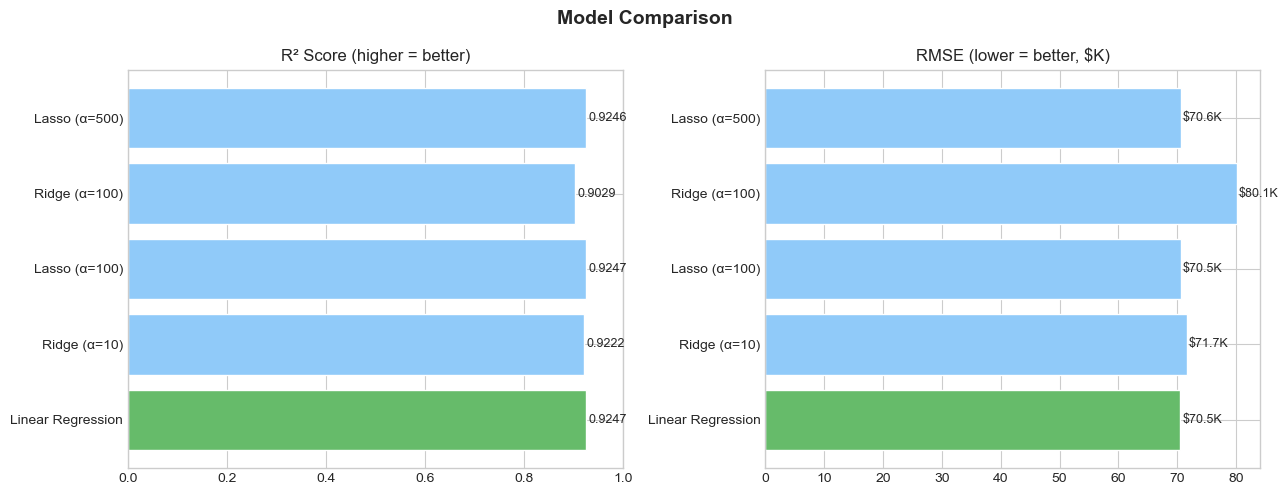

In [15]:
# --- Metrics Bar Chart ---
names = [r['name'] for r in results]
r2s   = [r['r2']   for r in results]
rmses = [r['rmse'] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

colors = ['#66BB6A' if n==best['name'] else '#90CAF9' for n in names]
axes[0].barh(names, r2s, color=colors, edgecolor='white')
axes[0].set_title('R² Score (higher = better)')
axes[0].set_xlim(0, 1)
for i, v in enumerate(r2s):
    axes[0].text(v+0.005, i, f'{v:.4f}', va='center', fontsize=9)

axes[1].barh(names, [r/1000 for r in rmses], color=colors, edgecolor='white')
axes[1].set_title('RMSE (lower = better, $K)')
for i, v in enumerate(rmses):
    axes[1].text(v/1000+0.3, i, f'${v/1000:.1f}K', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_model_compare.png', dpi=120, bbox_inches='tight')
plt.show()

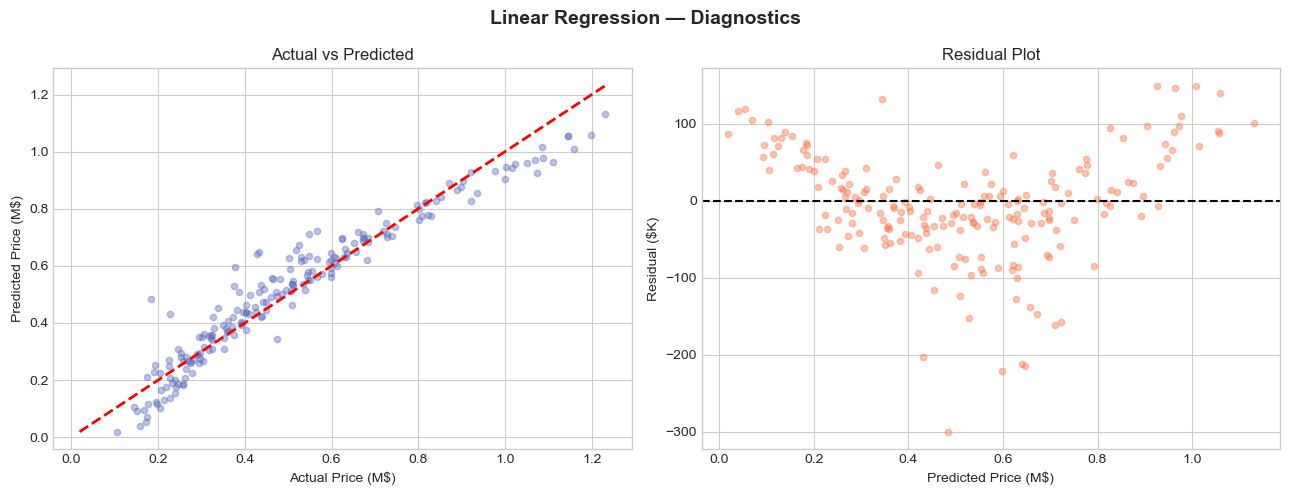

In [16]:
# --- Actual vs Predicted ---
preds = best['preds']
residuals = y_test.values - preds

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'{best["name"]} — Diagnostics', fontsize=14, fontweight='bold')

axes[0].scatter(y_test/1e6, preds/1e6, alpha=0.4, s=20, color='#5C6BC0')
lim = [min(y_test.min(), preds.min())/1e6, max(y_test.max(), preds.max())/1e6]
axes[0].plot(lim, lim, 'r--', lw=2)
axes[0].set_xlabel('Actual Price (M$)'); axes[0].set_ylabel('Predicted Price (M$)')
axes[0].set_title('Actual vs Predicted')

axes[1].scatter(preds/1e6, residuals/1e3, alpha=0.4, s=20, color='#FF7043')
axes[1].axhline(0, color='black', lw=1.5, ls='--')
axes[1].set_xlabel('Predicted Price (M$)'); axes[1].set_ylabel('Residual ($K)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.savefig('plot_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()

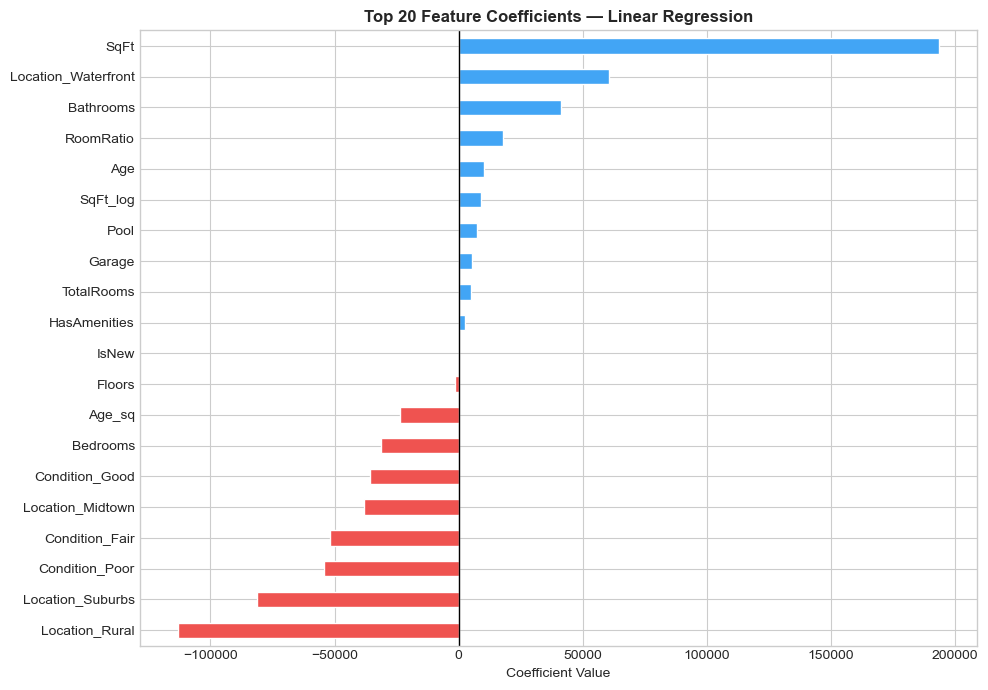

In [17]:
# --- Feature Importance ---
coefs = pd.Series(best['model'].coef_, index=feature_cols)
top20 = coefs.abs().nlargest(20).index
top_coefs = coefs[top20].sort_values()

plt.figure(figsize=(10, 7))
colors_coef = ['#EF5350' if v < 0 else '#42A5F5' for v in top_coefs]
top_coefs.plot(kind='barh', color=colors_coef, edgecolor='white')
plt.title(f'Top 20 Feature Coefficients — {best["name"]}', fontweight='bold')
plt.xlabel('Coefficient Value')
plt.axvline(0, color='black', lw=1)
plt.tight_layout()
plt.savefig('plot_features.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 💾 Step 6 — Save Model & Artifacts

In [18]:
joblib.dump(best['model'], 'house_model.pkl')
joblib.dump(scaler,        'house_scaler.pkl')

meta = {
    'feature_cols': feature_cols,
    'best_model':   best['name'],
    'r2':           round(best['r2'], 4),
    'rmse':         round(best['rmse'], 2),
    'mae':          round(best['mae'], 2)
}
with open('model_meta.json','w') as f:
    json.dump(meta, f, indent=2)

print('✅ Saved: house_model.pkl | house_scaler.pkl | model_meta.json')
print(json.dumps(meta, indent=2))

✅ Saved: house_model.pkl | house_scaler.pkl | model_meta.json
{
  "feature_cols": [
    "SqFt",
    "Bedrooms",
    "Bathrooms",
    "Age",
    "Garage",
    "Pool",
    "Floors",
    "RoomRatio",
    "TotalRooms",
    "IsNew",
    "HasAmenities",
    "SqFt_log",
    "Age_sq",
    "Location_Midtown",
    "Location_Rural",
    "Location_Suburbs",
    "Location_Waterfront",
    "Condition_Fair",
    "Condition_Good",
    "Condition_Poor"
  ],
  "best_model": "Linear Regression",
  "r2": 0.9247,
  "rmse": 70524.15,
  "mae": 51585.15
}


---
## 🌐 Step 7 — Flask Web App (runs inside Jupyter)

In [22]:
# ============================================================
# Write app.py
# ============================================================
flask_code = '''
from flask import Flask, request, jsonify, render_template_string
import joblib, json, numpy as np, pandas as pd

app = Flask(__name__)

model  = joblib.load("house_model.pkl")
scaler = joblib.load("house_scaler.pkl")
with open("model_meta.json") as f:
    meta = json.load(f)

FEATURE_COLS = meta["feature_cols"]

HTML = \'\'\'<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>House Price Predictor</title>
<link href="https://fonts.googleapis.com/css2?family=DM+Serif+Display&family=DM+Sans:wght@400;500;600&display=swap" rel="stylesheet">
<style>
  :root {
    --bg: #0f1117; --card: #1a1d27; --accent: #6C63FF;
    --accent2: #00D9A3; --text: #e8eaf6; --muted: #7c82a0;
    --border: #2a2d3e; --danger: #ff6b6b;
  }
  * { box-sizing: border-box; margin: 0; padding: 0; }
  body { background: var(--bg); color: var(--text); font-family: \'DM Sans\', sans-serif;
         min-height: 100vh; padding: 2rem 1rem; }
  .container { max-width: 780px; margin: auto; }
  header { text-align: center; margin-bottom: 2.5rem; }
  header h1 { font-family: \'DM Serif Display\', serif; font-size: 2.6rem;
               background: linear-gradient(135deg, var(--accent), var(--accent2));
               -webkit-background-clip: text; -webkit-text-fill-color: transparent; }
  header p  { color: var(--muted); margin-top: .5rem; font-size: .95rem; }
  .stats-bar { display: flex; gap: 1rem; margin-bottom: 2rem; flex-wrap: wrap; }
  .stat { flex: 1; min-width: 140px; background: var(--card); border: 1px solid var(--border);
           border-radius: 12px; padding: 1rem; text-align: center; }
  .stat .val { font-size: 1.4rem; font-weight: 600; color: var(--accent2); }
  .stat .lbl { font-size: .78rem; color: var(--muted); margin-top: .25rem; }
  .card { background: var(--card); border: 1px solid var(--border); border-radius: 16px; padding: 2rem; }
  .grid { display: grid; grid-template-columns: 1fr 1fr; gap: 1.2rem; }
  label { display: block; font-size: .85rem; color: var(--muted); margin-bottom: .4rem; font-weight: 500; }
  input, select {
    width: 100%; padding: .65rem .9rem; background: #12141e;
    border: 1px solid var(--border); border-radius: 8px;
    color: var(--text); font-size: .95rem; font-family: inherit;
    transition: border .2s;
  }
  input:focus, select:focus { outline: none; border-color: var(--accent); }
  select option { background: #1a1d27; }
  .btn { width: 100%; margin-top: 1.8rem; padding: .9rem; border: none; border-radius: 10px;
          background: linear-gradient(135deg, var(--accent), var(--accent2));
          color: #fff; font-size: 1.05rem; font-weight: 600; cursor: pointer;
          font-family: inherit; letter-spacing: .02em; transition: opacity .2s; }
  .btn:hover { opacity: .88; }
  .result-box { margin-top: 2rem; display: none; background: linear-gradient(135deg,#1d1a3a,#0d2a24);
                border: 1px solid var(--accent); border-radius: 14px; padding: 1.8rem; text-align: center; }
  .result-box .price { font-family: \'DM Serif Display\', serif; font-size: 2.8rem;
                        background: linear-gradient(90deg,var(--accent),var(--accent2));
                        -webkit-background-clip: text; -webkit-text-fill-color: transparent; }
  .result-box .sub  { color: var(--muted); font-size: .9rem; margin-top: .5rem; }
  .error-box { margin-top: 1.5rem; background: #2a1515; border: 1px solid var(--danger);
                border-radius: 10px; padding: 1rem; color: var(--danger); display: none; }
  .section-title { font-size: .8rem; text-transform: uppercase; letter-spacing: .1em;
                    color: var(--muted); margin-bottom: 1.2rem; border-bottom: 1px solid var(--border);
                    padding-bottom: .5rem; }
  @media(max-width:540px){ .grid{ grid-template-columns:1fr; } }
</style>
</head>
<body>
<div class="container">
  <header>
    <h1>🏠 House Price Predictor</h1>
    <p>ML-powered estimates using Linear Regression · Ridge · Lasso</p>
  </header>

  <div class="stats-bar">
    <div class="stat"><div class="val">{{ meta.best_model.split(\' \')[0] }}</div><div class="lbl">Best Algorithm</div></div>
    <div class="stat"><div class="val">{{ meta.r2 }}</div><div class="lbl">R² Score</div></div>
    <div class="stat"><div class="val">${{ "{:,.0f}".format(meta.rmse) }}</div><div class="lbl">RMSE</div></div>
    <div class="stat"><div class="val">${{ "{:,.0f}".format(meta.mae) }}</div><div class="lbl">MAE</div></div>
  </div>

  <div class="card">
    <div class="section-title">Property Details</div>
    <div class="grid">
      <div>
        <label>Location</label>
        <select id="location">
          <option>Suburbs</option><option>Downtown</option>
          <option>Midtown</option><option>Rural</option><option>Waterfront</option>
        </select>
      </div>
      <div>
        <label>Condition</label>
        <select id="condition">
          <option>Good</option><option>Excellent</option>
          <option>Fair</option><option>Poor</option>
        </select>
      </div>
      <div><label>Square Footage</label><input type="number" id="sqft" value="1800" min="300" max="10000"></div>
      <div><label>Bedrooms</label><input type="number" id="bedrooms" value="3" min="1" max="10"></div>
      <div><label>Bathrooms</label><input type="number" id="bathrooms" value="2" min="1" max="8"></div>
      <div><label>Property Age (years)</label><input type="number" id="age" value="10" min="0" max="100"></div>
      <div>
        <label>Garage Spaces</label>
        <select id="garage"><option value="0">None</option><option value="1">1 Car</option><option value="2">2 Cars</option></select>
      </div>
      <div>
        <label>Floors</label>
        <select id="floors"><option value="1">1</option><option value="2">2</option><option value="3">3</option></select>
      </div>
      <div>
        <label>Swimming Pool</label>
        <select id="pool"><option value="0">No</option><option value="1">Yes</option></select>
      </div>
    </div>
    <button class="btn" onclick="predict()">⚡ Predict Price</button>
    <div class="result-box" id="resultBox">
      <div class="price" id="priceDisplay"></div>
      <div class="sub" id="priceSub"></div>
    </div>
    <div class="error-box" id="errorBox"></div>
  </div>
</div>

<script>
async function predict() {
  const data = {
    location:  document.getElementById(\'location\').value,
    condition: document.getElementById(\'condition\').value,
    sqft:      +document.getElementById(\'sqft\').value,
    bedrooms:  +document.getElementById(\'bedrooms\').value,
    bathrooms: +document.getElementById(\'bathrooms\').value,
    age:       +document.getElementById(\'age\').value,
    garage:    +document.getElementById(\'garage\').value,
    floors:    +document.getElementById(\'floors\').value,
    pool:      +document.getElementById(\'pool\').value,
  };
  document.getElementById(\'resultBox\').style.display = \'none\';
  document.getElementById(\'errorBox\').style.display  = \'none\';
  try {
    const res = await fetch(\'/predict\', {
      method: \'POST\',
      headers: {\'Content-Type\': \'application/json\'},
      body: JSON.stringify(data)
    });
    const json = await res.json();
    if (json.error) throw new Error(json.error);
    const price = json.predicted_price;
    document.getElementById(\'priceDisplay\').textContent = \'$\' + price.toLocaleString();
    document.getElementById(\'priceSub\').textContent = \'Estimated market value · \' + data.sqft + \' sq ft · \' + data.location;
    document.getElementById(\'resultBox\').style.display = \'block\';
  } catch(e) {
    document.getElementById(\'errorBox\').textContent = \'Error: \' + e.message;
    document.getElementById(\'errorBox\').style.display = \'block\';
  }
}
</script>
</body></html>\'\'\'  

@app.route("/")
def index():
    return render_template_string(HTML, meta=meta)

@app.route("/predict", methods=["POST"])
def predict():
    try:
        d = request.get_json()
        sqft      = float(d["sqft"])
        bedrooms  = float(d["bedrooms"])
        bathrooms = float(d["bathrooms"])
        age       = float(d["age"])
        garage    = float(d["garage"])
        pool      = float(d["pool"])
        floors    = float(d["floors"])
        location  = d["location"]
        condition = d["condition"]

        row = {
            "SqFt":sqft, "Bedrooms":bedrooms, "Bathrooms":bathrooms,
            "Age":age,   "Garage":garage,     "Pool":pool, "Floors":floors,
            "IsNew":     int(age<=5),
            "HasAmenities": int(pool==1 or garage>=1),
            "RoomRatio": bedrooms/(bathrooms+1),
            "TotalRooms":bedrooms+bathrooms,
            "SqFt_log":  np.log1p(sqft),
            "Age_sq":    age**2,
        }
        for loc in ["Downtown","Midtown","Rural","Suburbs","Waterfront"]:
            key = f"Location_{loc}"
            if key in FEATURE_COLS:
                row[key] = 1 if location==loc else 0
        for cond in ["Excellent","Fair","Good","Poor"]:
            key = f"Condition_{cond}"
            if key in FEATURE_COLS:
                row[key] = 1 if condition==cond else 0

        X = pd.DataFrame([row])
        for c in FEATURE_COLS:
            if c not in X.columns:
                X[c] = 0
        X = X[FEATURE_COLS]
        X_s = scaler.transform(X)
        price = float(model.predict(X_s)[0])
        price = max(50000, round(price, -2))
        return jsonify({"predicted_price": price})
    except Exception as e:
        return jsonify({"error": str(e)}), 400

if __name__ == "__main__":
    app.run(port=5000, debug=False, use_reloader=False)
'''
with open('app.py', 'w', encoding='utf-8', errors='replace') as f:
    f.write(flask_code)


print('✅ app.py written!')

✅ app.py written!


In [23]:
# ============================================================
# Launch Flask in a background thread
# ============================================================
import importlib, threading
from flask import Flask

# Kill any existing Flask on 5000
import socket
def port_in_use(port):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        return s.connect_ex(('localhost', port)) == 0

if port_in_use(5000):
    print('⚠️  Port 5000 already in use — server may already be running.')
else:
    def run_flask():
        import subprocess
        subprocess.Popen(['python', 'app.py'])

    t = threading.Thread(target=run_flask, daemon=True)
    t.start()

    import time; time.sleep(2)
    if port_in_use(5000):
        print('✅ Flask server started!')
    else:
        print('⚠️  Server may still be starting...')

print('\n🌐 Open in your browser: http://localhost:5000')

✅ Flask server started!

🌐 Open in your browser: http://localhost:5000


In [ ]:
# ============================================================
# Embed the app inside the notebook via IFrame
# ============================================================
from IPython.display import IFrame, display
import time; time.sleep(1)
display(IFrame('http://localhost:5000', width='100%', height=650))

---
## ✅ Project Summary

| Step | Description |
|------|-------------|
| 1 | Libraries imported |
| 2 | Synthetic dataset (1 000 houses, 10 features, ~5% missing) |
| 3 | EDA — distributions, categorical analysis, scatter plots |
| 4 | Data cleaning + 7 engineered features (PricePerSqFt, RoomRatio, IsNew…) |
| 5 | Linear Regression, Ridge, Lasso trained + evaluated (R², RMSE, MAE, CV) |
| 6 | Best model saved as `house_model.pkl` |
| 7 | Flask web app — live predictions in browser / embedded IFrame |

**To restart the server:** Re-run the two cells in Step 7.